## Passo 1

Primeiramente, vou usar a biblioteca ```os``` para garantir que tudo funcione, não importando em que máquina (diferentes árvores de diretórios) ou sistema operacional (barra normal ou invertida) o código é rodado.

Esse passo é como escrever a partitura que será dada a cada um dos comandos dessa filarmônica.

In [1]:
import os

current_dir = os.path.abspath('')
base_dir = os.path.dirname(current_dir)

schema_path = os.path.join(base_dir, 'sql', 'schema.sql')
seed_path = os.path.join(base_dir, 'sql', 'seed.sql')
db_path = os.path.join(base_dir, 'data', 'database.db')

if '\\' in db_path:
  db_path = db_path.replace('\\', '/')

Já que se trata de uma loja de música, por que não climatizar com [isso](https://youtu.be/wocjCxPtgwM?list=PLQCIdhRuk6I4v_mNEIFbc6OJinmYGfhW7)?

In [2]:
from sqlalchemy import create_engine, inspect, text

engine = create_engine(f'sqlite:///{db_path}')

In [3]:
try:
  inspector = inspect(engine)
  print(f'Banco de dados conectado com sucesso em: {db_path}')
except Exception as e:
  print(f'Erro: {e}')

Banco de dados conectado com sucesso em: /home/ryann/Documentos/Estudos/Projetos/Repositórios/symphony-sql/data/database.db


Criando o banco de dados com base nas instruções do schema.sql e do seed.sql. Darei .strip() para garantir que não fiquem espaços em branco no final da string gigante.

In [4]:
with open(schema_path, 'r') as f:
  statements = f.read().strip()

with open(seed_path, 'r') as f:
  statements2 = f.read().strip()

# Como o schema.sql tem várias instruções, vou fazer uma conexão crua, direta com o sqlite3.
# Fiz isso já que o sql alchemy tenta padronizar tudo, e outros SGBDs não toleram execução de script com mais de uma instrução
# Por isso, é necessário se conectar diretamente com o sqlite3 através de uma conexão crua para usar os comandos específicos dele.
raw = engine.raw_connection()

# A conexão crua não consegue suportar um objeto text, que é do sql alchemy
try:
  raw.executescript(statements)
  raw.executescript(statements2)
  raw.commit()
finally:
  raw.close()

Agora, confirmando se está tudo certo e conferindo os nomes das tabelas do schema.

In [5]:
inspector.get_table_names()

['clientes', 'itens_pedidos', 'pedidos', 'produtos']

## Passo 2

Começo pegando as visualizações de todas as tabelas no formato [pd.DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)

In [6]:
with engine.connect() as conn:
  query = conn.execute(text('SELECT * FROM clientes'))

In [7]:
clientes = query.fetchall()
clientes

[(1, 'Ana Silva'),
 (2, 'Bruno Costa'),
 (3, 'Carla Koch'),
 (4, 'Diogo Melo'),
 (5, 'Fernanda Lima'),
 (6, 'Gerhard Kremer'),
 (7, 'Helena Reis'),
 (8, 'Igor Dias'),
 (9, 'Juliana Vogel'),
 (10, 'Kassia Fontes'),
 (11, 'Lucas Rocha'),
 (12, 'Mariana Paz'),
 (13, 'Natan Schneider'),
 (14, 'Otávio Martins'),
 (15, 'Poliana Mendes'),
 (16, 'Quiteria Lins'),
 (17, 'Rafael Vogel'),
 (18, 'Sophie Hoffmann'),
 (19, 'Tiago Viana'),
 (20, 'Vitor Hugo'),
 (21, None),
 (22, None),
 (23, None),
 (24, None),
 (25, None),
 (26, None),
 (27, None),
 (28, None),
 (29, None),
 (30, None)]

Importante destacar que os últimos 10 clientes tem nome nulo, pois fizeram a compra sem registrar nome. Mesmo assim, são distinguíveis por id

In [8]:
import pandas as pd

clientes = pd.DataFrame(clientes).set_index('id')

In [9]:
clientes

,nome
id,
1,Ana Silva
2,Bruno Costa
3,Carla Koch
4,Diogo Melo
5,Fernanda Lima
6,Gerhard Kremer
7,Helena Reis
8,Igor Dias
9,Juliana Vogel


Vou automatizar o processo com uma função

In [10]:
def to_pd(query, full_table = False):
  with engine.connect() as conn:
    result = conn.execute(text(query))
    if full_table == True:
      # Vou dar set_index de todas para "id" porque sei que esse é o nome de todas
      # as PKs do schema, mas reconheço que nem sempre é assim
      df = pd.DataFrame(result.fetchall()).set_index('id')
    else:
      df = pd.DataFrame(result.fetchall())
  return df

In [11]:
to_pd('SELECT * FROM produtos', True)

,nome,preco
id,,
1,Violão Clássico,500
2,Flauta Irlandesa,80
3,Baixo Jazz Bass,2800
4,Teclado Digital,2200
5,Bateria Acústica,4500
6,Cravo Barroco,9800
7,Ukulele,300
8,Microfone Condensador,800
9,Mesa de Som 12 canais,1500


In [12]:
to_pd('SELECT * FROM pedidos', True)

,id_cliente,data
id,,
1,1,2025-11-05
2,2,2025-11-10
3,3,2025-11-15
4,4,2025-11-20
5,5,2025-11-25
...,...,...
58,6,2025-12-24
59,7,2025-12-24
60,8,2025-12-24


In [13]:
to_pd('SELECT * FROM itens_pedidos', True)

,id_pedido,id_produto,quantidade,preco_venda_unitario
id,,,,
1,22,13,5,30
2,55,12,2,50
3,9,13,10,30
4,16,12,3,50
5,39,1,1,500
...,...,...,...,...
64,37,8,1,800
65,48,12,2,50
66,49,3,1,2800


Agora que já tomamos conhecimento da "fisionomia" do banco de dados por completo, vamos começar a cumprir as tarefas da diretoria fictícia! São 10 afazeres ficcionais que possivelmente lhes trarão benefício (ficcional, é claro), quem sabe uma visão extra de algum problema ou evidências úteis de fatos.

## Passo 3

As 10 tarefas são:

1. Registre dados de algumas vendas da loja física que atrasaram no cadastro ou tiveram cadastro incompleto.
2. Quanto lucramos no período listado?
3. Em quais datas vendemos mais?
4. Qual é o ticket médio da compra?
5. Algum cliente registrado não comprou nada? Se sim, qual (is)?
6. Queremos enviar um agradecimento pela confiança aos clientes que compraram algum de nossos três produtos mais caros. Retorne a lista de seus nomes.
7. Queremos uma forma de ver o faturamento por produto, mas sem precisar criar outra tabela, nem calcular repetidas vezes.
8. Agora, queremos saber a quantidade de pedidos por cliente.
9. Quais produtos venderam mais?
10. Quais produtos não registraram nenhuma venda?



### Tarefa 1

***"Registre dados de algumas vendas da loja física que atrasaram no cadastro ou tiveram cadastro incompleto."***

In [14]:
path = os.path.join(base_dir, 'sql', 'new.sql')

with open(path, 'r') as f:
  statements3 = f.read().strip()

raw = engine.raw_connection()

try:
  raw.executescript(statements3)
  raw.commit()
finally:
  raw.close()

### Tarefa 2

***"Quanto lucramos no período listado?"***

In [15]:
query = '''
SELECT SUM(quantidade * preco_venda_unitario) AS total_vendas
FROM itens_pedidos;
'''
faturamento_total = to_pd(query)
faturamento_total

,total_vendas
0,45920


### Tarefa 3

***"Em quais datas vendemos mais?"***

Primeiro, vamos ver as datas organizadas em critério de número de vendas, depois, por faturamento.

In [16]:
query = '''
SELECT data, COUNT(id) AS num_vendas
FROM pedidos
GROUP BY data
ORDER BY num_vendas DESC
'''
vendas_diarias = to_pd(query)
vendas_diarias

,data,num_vendas
0,2025-11-28,21
1,2025-12-06,14
2,2025-12-24,3
3,2025-12-05,3
4,2025-12-25,2
5,2025-11-27,2
6,2025-12-23,1
7,2025-12-17,1
8,2025-12-14,1
9,2025-12-12,1


In [17]:
query = '''
SELECT SUM(ip.quantidade * ip.preco_venda_unitario) AS receita_diaria, p.data
FROM itens_pedidos ip JOIN pedidos p
ON ip.id_pedido = p.id
GROUP BY p.data
ORDER BY receita_diaria DESC;
'''
faturamento_diario = to_pd(query)
faturamento_diario

,receita_diaria,data
0,15780,2025-12-06
1,14100,2025-11-28
2,4500,2025-12-03
3,2650,2025-11-20
4,2280,2025-11-15
5,1720,2025-12-05
6,500,2025-11-05
7,450,2025-12-08
8,450,2025-12-01
9,450,2025-11-29


A diretoria da loja acha muito estranho o fato de, nessa localidade (breve explicação na README.md), o dia 06/12 compete com a própria Black Friday (no ano de 2025, foi 28/11).

Buscando por um fator que pudesse explicar isso, encontrei uma antiga tradição do lugar ─ que é de colonização germânica ─ de fazer a troca de presentes de fim de ano no dia de São Nicolau, que é o 06 de dezembro. Isso também explica as poucas vendas no Natal (e os sobrenomes, por óbvio). Veja:


In [18]:
# Primeiro vou transformar a coluna data para datetime, mas só vou usar a de faturamento mais tarde

vendas_diarias['data'] = pd.to_datetime(vendas_diarias['data'], format='%Y-%m-%d')
faturamento_diario['data'] = pd.to_datetime(faturamento_diario['data'], format='%Y-%m-%d')

black_friday = pd.to_datetime('2025-11-28')
sao_nicolau = pd.to_datetime('2025-12-06')

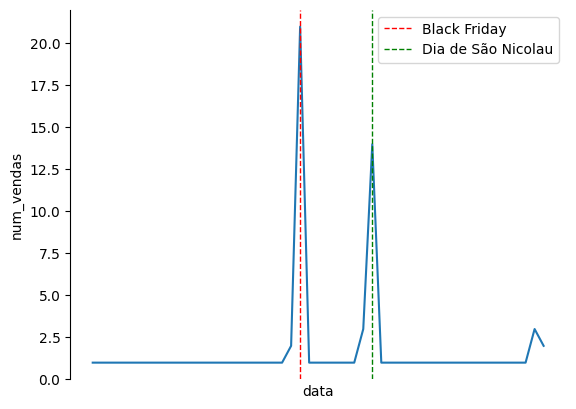

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.lineplot(data=vendas_diarias, x=vendas_diarias['data'], y=vendas_diarias['num_vendas'])
sns.despine(bottom=True)
plt.xticks([])

plt.axvline(x=black_friday, color='red', linestyle='--',
            linewidth=1, label='Black Friday')
plt.axvline(x=sao_nicolau, color='green', linestyle='--',
            linewidth=1, label='Dia de São Nicolau')

plt.legend()
plt.show()

### Tarefa 4

***"Qual é o ticket médio da compra?"***

Primeiro vou calcular o ticket médio geral. Só pra constar, a fórmula é:
$$Ticket\ médio = \frac{Faturamento}{Número\ de\ vendas}$$

In [20]:
# Felizmente já tenho a variável faturamento_total, e o número de vendas é simples

query = '''
SELECT COUNT(id) FROM pedidos;
'''

num_vendas = to_pd(query)

In [21]:
ticket_medio_geral = faturamento_total.squeeze() / num_vendas.squeeze()
print(ticket_medio_geral)

717.5


Agora, vou calcular o ticket médio diário.

In [22]:
df_unificado = pd.merge(vendas_diarias, faturamento_diario, on='data')
df_unificado

,data,num_vendas,receita_diaria
0,2025-11-28,21,14100
1,2025-12-06,14,15780
2,2025-12-24,3,340
3,2025-12-05,3,1720
4,2025-12-25,2,110
5,2025-11-27,2,130
6,2025-12-23,1,300
7,2025-12-17,1,80
8,2025-12-14,1,50
9,2025-12-12,1,100


In [23]:
df_unificado['ticket_medio'] = round((df_unificado['receita_diaria'] / df_unificado['num_vendas']), 2)
df_unificado.sort_values(by='data')

,data,num_vendas,receita_diaria,ticket_medio
24,2025-11-05,1,500,500.00
23,2025-11-10,1,450,450.00
22,2025-11-15,1,2280,2280.00
21,2025-11-20,1,2650,2650.00
20,2025-11-25,1,300,300.00
19,2025-11-26,1,390,390.00
5,2025-11-27,2,130,65.00
0,2025-11-28,21,14100,671.43
18,2025-11-29,1,450,450.00
17,2025-11-30,1,50,50.00


### Tarefa 5

***"Algum cliente registrado não comprou nada? Se sim, qual (is)?"***

In [24]:
path = os.path.join(base_dir, 'sql', 'joins', 'join1.sql')

with open(path, 'r') as f:
  statements4 = f.read().strip()

to_pd(statements4)

# Só a título de curiosidade, a consulta era:
# SELECT c.id, c.nome
# FROM clientes c LEFT JOIN pedidos p
# ON c.id = p.id_cliente
# WHERE p.id IS NULL;

,id,nome
0,12,Mariana Paz


Confirmando que, de fato, Dª Mariana não tem nenhuma compra:

In [25]:
to_pd('SELECT * FROM pedidos WHERE id_cliente = 12')

""


É um join simples, mas intenso.

Um comentário: é realmente interessante (e até necessária) a apreciação (no sentido de análise) da lógica subjacente quando se usa esse tipo de instrução, não é? Aliás, buscar uma intuitividade maior é o motivo pelo qual eu deixo a cláusula **join** junto do **from**, e o **on** numa linha separada, aproveitando que no caso há só um join.

### Tarefa 6

***"Queremos enviar um agradecimento pela confiança aos clientes que compraram algum de nossos três produtos mais caros. Retorne a lista de seus nomes."***

In [26]:
query = '''
SELECT p.id_cliente, c.nome
FROM pedidos p JOIN clientes c
ON p.id_cliente = c.id
WHERE p.id IN (SELECT id_pedido FROM itens_pedidos WHERE id_produto IN (SELECT id FROM produtos ORDER BY preco DESC LIMIT 3));
'''
to_pd(query)

,id_cliente,nome
0,7,Helena Reis
1,19,Tiago Viana


No entanto, essa forma é bem confusa e propensa a erros. Afinal de contas, para lê-la, embora funcione, precisamos mergulhar em parênteses dentro de parênteses, tudo isso sem equipamento de proteção. Existe uma opção que desmacarroniza tudo isso: CTE (Common Table Expression).

É a batuta do regente, para a orquestra que já estava desanimada!

In [27]:
query = '''
WITH produtos_caros AS (
    SELECT id FROM produtos ORDER BY preco DESC LIMIT 3
),
pedidos_confianca AS (
    SELECT id_pedido FROM itens_pedidos WHERE id_produto IN produtos_caros
)

SELECT p.id_cliente, c.nome
FROM pedidos p JOIN clientes c
ON p.id_cliente = c.id
WHERE p.id IN pedidos_confianca;
'''
to_pd(query)

,id_cliente,nome
0,7,Helena Reis
1,19,Tiago Viana


Com a CTE, tudo parece mais lógico e simples de entender.

### Tarefa 7

***"Queremos uma forma de ver o faturamento por produto, mas sem precisar criar outra tabela, nem calcular repetidas vezes."***

In [28]:
# A consulta que cria essa view é
query = '''
SELECT p.nome, SUM(ip.quantidade*ip.preco_venda_unitario) AS faturamento_produto
FROM produtos p LEFT JOIN itens_pedidos ip
ON p.id = ip.id_produto
GROUP BY p.id;
'''
to_pd(query)

,nome,faturamento_produto
0,Violão Clássico,4000.0
1,Flauta Irlandesa,240.0
2,Baixo Jazz Bass,8400.0
3,Teclado Digital,4400.0
4,Bateria Acústica,4500.0
5,Cravo Barroco,9800.0
6,Ukulele,2400.0
7,Microfone Condensador,3200.0
8,Mesa de Som 12 canais,1500.0
9,Amplificador Valvulado,NaN


Contudo, vou adicionar outra coisa, ainda. Classificarei os produtos por faixa de faturamento. É perfeito para cruzar com a quantidade de vendas e encontrar os produtos deluxe, os carros-chefes e os "feijões com arroz" que equilibram preço e quantidade de vendas. Aparentemente, se eu não usar duplo group by, SGBD's mais exigentes dariam peti e esperneariam por não poderem se certificar que não há mais de um nome de produto por id de produto. No caso específico atual, como está dá certo. O script completo fica abaixo

In [29]:
instrucao = '''
CREATE VIEW faturamento_produtos AS
SELECT
p.nome,
SUM(ip.quantidade*ip.preco_venda_unitario) AS faturamento_produto,
CASE
WHEN SUM(ip.quantidade*ip.preco_venda_unitario) < 1000
  OR SUM(ip.quantidade*ip.preco_venda_unitario) IS NULL THEN 'Classe C'
WHEN SUM(ip.quantidade*ip.preco_venda_unitario) BETWEEN 1000 AND 3000 THEN 'Classe B'
ELSE 'Classe A'
END AS categoria_faturamento
FROM produtos p LEFT JOIN itens_pedidos ip
ON p.id = ip.id_produto
GROUP BY p.id;
'''
with engine.connect() as conn:
  conn.execute(text(instrucao))

to_pd('SELECT * FROM faturamento_produtos')

,nome,faturamento_produto,categoria_faturamento
0,Violão Clássico,4000.0,Classe A
1,Flauta Irlandesa,240.0,Classe C
2,Baixo Jazz Bass,8400.0,Classe A
3,Teclado Digital,4400.0,Classe A
4,Bateria Acústica,4500.0,Classe A
5,Cravo Barroco,9800.0,Classe A
6,Ukulele,2400.0,Classe B
7,Microfone Condensador,3200.0,Classe A
8,Mesa de Som 12 canais,1500.0,Classe B
9,Amplificador Valvulado,NaN,Classe C


Importante notar que os limiares que defini são arbitrários. Não estou usando totalmente a lógica da curva ABC, até mesmo porque descobri sua existência enquanto prática consolidada no momento em que escrevia essa parte!

### Tarefa 8

***"Agora, queremos saber a quantidade de pedidos por cliente."***

Vou limitar aos primeiros resultados para não poluir tanto a vista. Novamente, estou rodando via arquivo .sql só para dizer "vejam como eu acho que consigo rodar scripts com statements!"

In [30]:
path = os.path.join(base_dir, 'sql', 'joins', 'join2.sql')

with open(path, 'r') as f:
  statements5 = f.read().strip()

to_pd(statements5)

# De novo, a consulta era:
# SELECT c.nome, COUNT(p.id) AS quantidade_pedidos
# FROM clientes c JOIN pedidos p
# ON c.id = p.id_cliente
# GROUP BY c.id
# ORDER BY quantidade_pedidos DESC
# LIMIT 15;

,nome,quantidade_pedidos
0,Vitor Hugo,3
1,Natan Schneider,3
2,Kassia Fontes,3
3,Juliana Vogel,3
4,Igor Dias,3
5,Helena Reis,3
6,Gerhard Kremer,3
7,Fernanda Lima,3
8,Diogo Melo,3
9,Carla Koch,3


Claro que a regularidade quase total é pelos dados serem fictícios, mas em uma empresa real, é claro que mostraria alguma coisa bem mais *real*.

### Tarefa 9

***"Quais produtos venderam mais?"***

In [31]:
query = '''
SELECT p.nome, COUNT(ip.id_produto) as vendas_produto
FROM itens_pedidos ip JOIN produtos p
ON ip.id_produto = p.id
GROUP BY ip.id_produto
ORDER BY vendas_produto DESC;
'''
vendas_produtos = to_pd(query)
vendas_produtos

,nome,vendas_produto
0,Palhetas (pack 10),15
1,Cordas para Violão,15
2,Pedal de Distortion,10
3,Ukulele,8
4,Violão Clássico,8
5,Microfone Condensador,4
6,Baixo Jazz Bass,3
7,Flauta Irlandesa,3
8,Teclado Digital,2
9,Mesa de Som 12 canais,1


### Tarefa 10

***"Quais produtos não registraram nenhuma venda?"***

A consulta anterior, por ser um inner join, só retorna casos em que produtos tinham sido vendidos, mas não retorna os que não registraram nenhuma venda. Mas isso pode ser resolvido modificando-a um pouco, usando um left join.

In [32]:
query = '''
SELECT p.nome, COUNT(ip.id_produto) as vendas_produto
FROM produtos p LEFT JOIN itens_pedidos ip
ON ip.id_produto = p.id
GROUP BY ip.id_produto
HAVING vendas_produto = 0;
'''
to_pd(query)

,nome,vendas_produto
0,Amplificador Valvulado,0


Então está respondido! O amplificador valvulado foi o único produto sem vendas. Quem sabe deveriam substituí-lo por algo na linha dos mais vendidos, ou então também fazer uma queima de estoque dele...

## Extra: Nuvem de palavras

In [33]:
query = '''
SELECT c.nome, COUNT(p.id_cliente) AS num_pedidos
FROM clientes c JOIN pedidos p
ON c.id = p.id_cliente
GROUP BY p.id_cliente
HAVING c.nome NOT NULL
ORDER BY c.nome;
'''

In [34]:
clientes = to_pd(query)['nome']
freq_clientes = to_pd(query)['num_pedidos']

In [35]:
freq_por_termo = {}
for cliente, freq in zip(clientes, freq_clientes):
  freq_por_termo[cliente] = freq
freq_por_termo

{'Ana Silva': 3,
 'Bruno Costa': 3,
 'Carla Koch': 3,
 'Diogo Melo': 3,
 'Fernanda Lima': 3,
 'Gerhard Kremer': 3,
 'Helena Reis': 3,
 'Igor Dias': 3,
 'Juliana Vogel': 3,
 'Kassia Fontes': 3,
 'Lucas Rocha': 2,
 'Natan Schneider': 3,
 'Otávio Martins': 2,
 'Poliana Mendes': 2,
 'Quiteria Lins': 2,
 'Rafael Vogel': 2,
 'Sophie Hoffmann': 2,
 'Tiago Viana': 2,
 'Vitor Hugo': 3}

In [36]:
for produto, freq in zip(vendas_produtos['nome'].tolist(), vendas_produtos['vendas_produto'].tolist()):
  # Estou dando uma correção arbitrária para que os nomes dos produtos não fiquem gigantes
  freq_por_termo[produto] = (round(freq/1.5) if freq > 3 else freq)
freq_por_termo

{'Ana Silva': 3,
 'Bruno Costa': 3,
 'Carla Koch': 3,
 'Diogo Melo': 3,
 'Fernanda Lima': 3,
 'Gerhard Kremer': 3,
 'Helena Reis': 3,
 'Igor Dias': 3,
 'Juliana Vogel': 3,
 'Kassia Fontes': 3,
 'Lucas Rocha': 2,
 'Natan Schneider': 3,
 'Otávio Martins': 2,
 'Poliana Mendes': 2,
 'Quiteria Lins': 2,
 'Rafael Vogel': 2,
 'Sophie Hoffmann': 2,
 'Tiago Viana': 2,
 'Vitor Hugo': 3,
 'Palhetas (pack 10)': 10,
 'Cordas para Violão': 10,
 'Pedal de Distortion': 7,
 'Ukulele': 5,
 'Violão Clássico': 5,
 'Microfone Condensador': 3,
 'Baixo Jazz Bass': 3,
 'Flauta Irlandesa': 3,
 'Teclado Digital': 2,
 'Mesa de Som 12 canais': 1,
 'Cravo Barroco': 1,
 'Bateria Acústica': 1}

In [37]:
from wordcloud import WordCloud

In [38]:
wordcloud = WordCloud(background_color='white', width=1600, height=800, colormap = 'viridis')

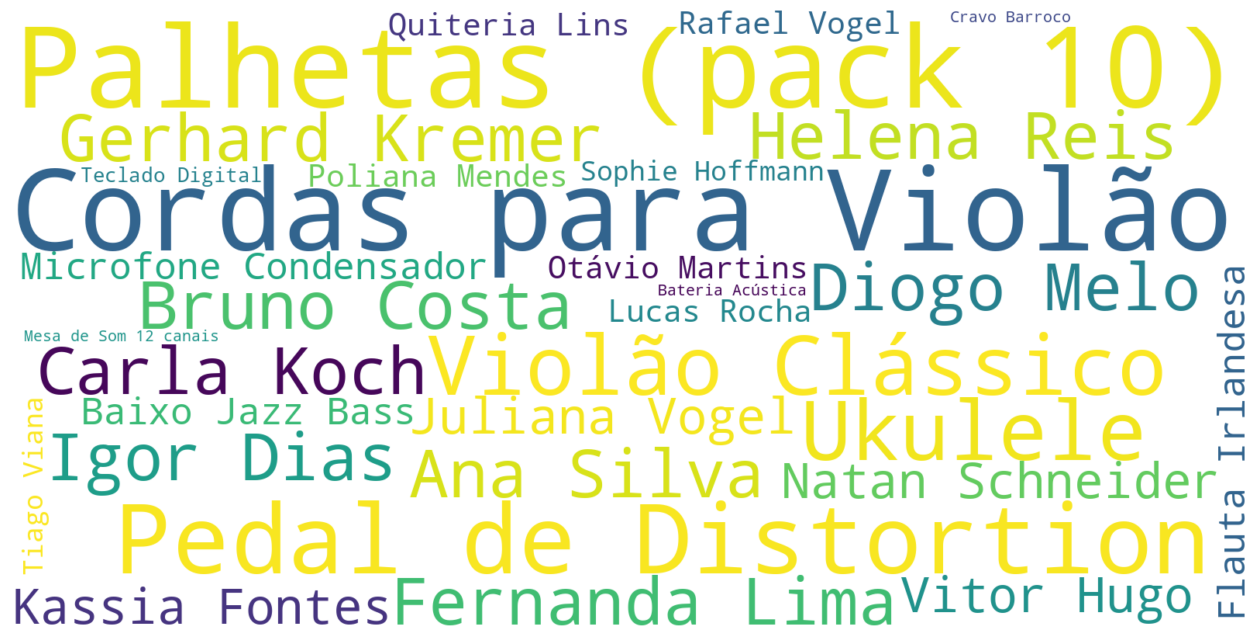

In [39]:
wordcloud.generate_from_frequencies(frequencies = freq_por_termo)
fig, ax = plt.subplots(figsize=(16,12))
plt.imshow(wordcloud, interpolation = 'bilinear')
ax.axis("off")
plt.show()